<a href="https://colab.research.google.com/github/ryoder96/clinical-nlp-uncertainty/blob/main/NLP_Project_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clinical NLP — Uncertainty-Aware Specialty Routing
### MSBX 5425 | University of Colorado | 2026

---

## Project Overview
We fine-tune ClinicalBERT on unstructured medical transcriptions to classify
notes by medical specialty — and instead of always outputting a single confident
answer, we use **conformal prediction** to output a set of possible specialties
that reflects how certain the model is.

**Core question:** Can we build a model that not only routes clinical notes to
the right specialty, but reliably signals when it shouldn't be trusted?

---

## Repository
`github.com/ryoder96/clinical-nlp-uncertainty`

---

## Setup Instructions

### 1. Upload the dataset
Download MTSamples from Kaggle:
`https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions`

Upload `mtsamples.csv` to this Colab session:
```python
from google.colab import files
uploaded = files.upload()
```
Or mount Google Drive if the file is already there (recommended):
```python
from google.colab import drive
drive.mount('/content/drive')
```

### 2. GPU Runtime (required for training)
`Runtime → Change runtime type → T4 GPU`
Do this before running any training cells or it will time out.

### 3. Install dependencies
Run the first code cell — it installs all required libraries.

### 4. Saving your work
Always save back to GitHub after a working session:
`File → Save a copy in GitHub`
Write a short commit message describing what you changed.
**Clear outputs first:** `Edit → Clear all outputs` before saving.

---

## Notebook Structure
| Section | Description |
|---|---|
| 1. Setup & Imports | Install libraries, mount Drive |
| 2. Data Loading & EDA | Load MTSamples, clean and explore |
| 3. Preprocessing | Label encoding, train/cal/test split |
| 4. Model Training | Fine-tune ClinicalBERT |
| 5. Embeddings | Extract CLS embeddings and softmax scores |
| 6. Conformal Prediction | Calibration, prediction sets, coverage |
| 7. Outlier Detection | k-NN density scoring in embedding space |
| 8. Evaluation | Coverage, efficiency, calibration curve |
| 9. Error Analysis | Confusion matrix, confident failures |
| 10. Stress Testing | Noise injection, synthetic hard cases |
| 11. Explainability | scispaCy span tagging, nearest neighbors |
| 12. Conclusions | Findings, limitations, future work |

---

## Authors
- **Rebecca Yoder, Ariadnee Ziady**

## This Notebook explores the Kaggle dataset mtsamples
More info tbd

In [1]:
# In Colab
!pip install kaggle
!kaggle datasets download -d tboyle10/medicaltranscriptions

Dataset URL: https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions
License(s): CC0-1.0
medicaltranscriptions.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
!unzip medicaltranscriptions.zip

Archive:  medicaltranscriptions.zip
replace mtsamples.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [3]:
# =============================================
# STEP 1: Load and inspect
# =============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mtsamples.csv', index_col=0)

print(df.shape)
print(df.columns.tolist())
df.head(2)

(4999, 5)
['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."


In [4]:
df.head()

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


### Notes on step 1 cell:
* transcription = NLP input
* medical specialty = label

In [5]:
# =============================================
# STEP 2: Missing values
# =============================================
print(df.isnull().sum())
print(f"\nMissing transcriptions: {df['transcription'].isnull().sum()}")
print(f"Missing specialties: {df['medical_specialty'].isnull().sum()}")

# Drop rows with missing transcription or specialty — unusable for us
df = df.dropna(subset=['transcription', 'medical_specialty'])
print(f"\nRows after dropping nulls: {len(df)}")

description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Missing transcriptions: 33
Missing specialties: 0

Rows after dropping nulls: 4966


### Notes on Step 2 cell:
* 33 missing transcriptions - we'll drop those
* 1,068 missing keywords - don't care

medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Psychiatry / Psychology            53
Office Notes                       50
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

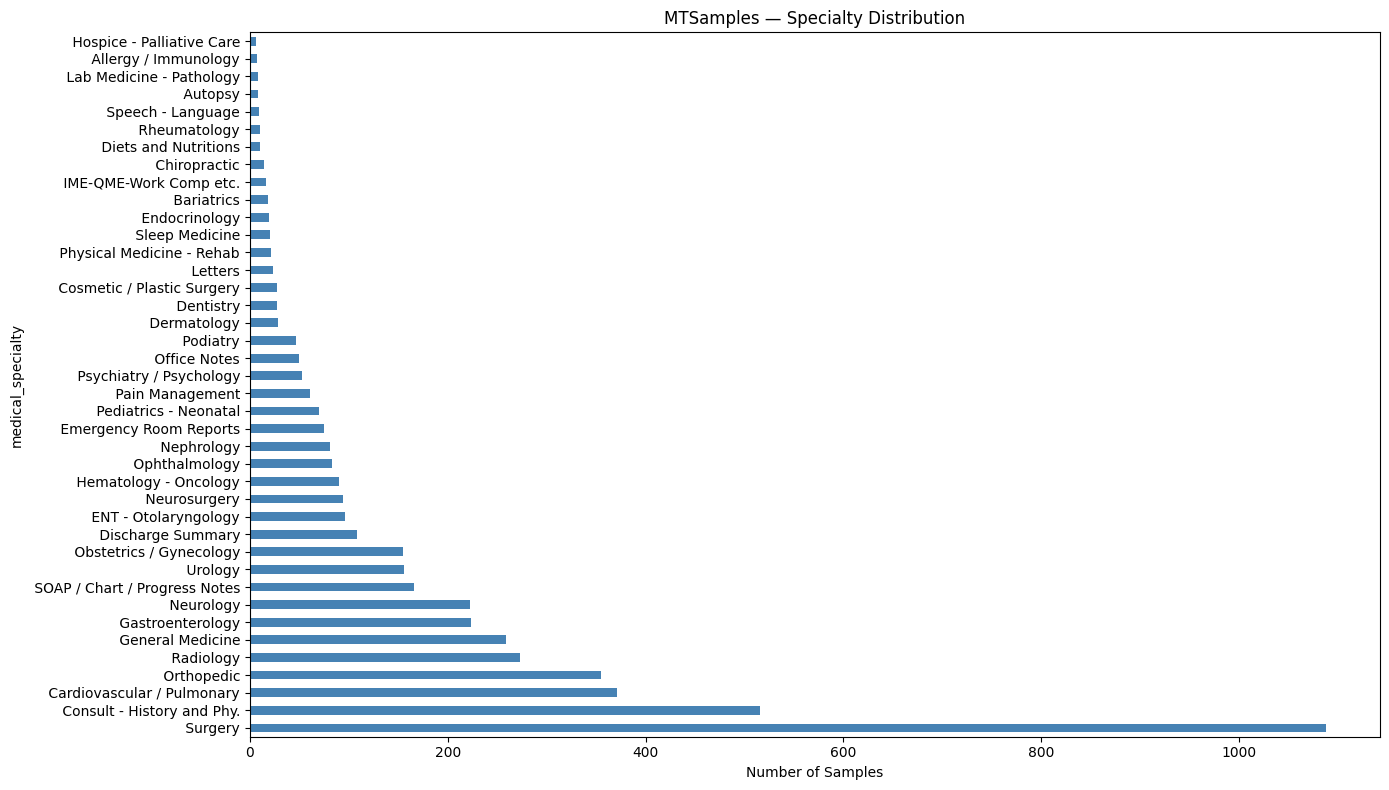

In [6]:
# =============================================
# STEP 3: Class distribution — the critical one
# =============================================
specialty_counts = df['medical_specialty'].value_counts()
print(specialty_counts)
print(f"\nNumber of unique specialties: {df['medical_specialty'].nunique()}")
print(f"Classes with fewer than 50 samples: {(specialty_counts < 50).sum()}")
print(f"Classes with fewer than 20 samples: {(specialty_counts < 20).sum()}")

# Visualize
plt.figure(figsize=(14, 8))
specialty_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Samples')
plt.title('MTSamples — Specialty Distribution')
plt.tight_layout()
plt.show()

### Notes on Step 3 cell:
Drop:
* Consult
* SOAP
* Discharge summary
* Office notes
* Letters
* IME_QME-WORK Comp
* Lab medicine

Potential Drops due to Scarcity:
* Podiatry and below

In [7]:
# =============================================
# STEP 3b: Drop categories we don't want
# =============================================
df['medical_specialty'] = df['medical_specialty'].str.strip()

# Now redo the drop
specialty_counts = df['medical_specialty'].value_counts()
small_classes = specialty_counts[specialty_counts < 30].index.tolist()

drop_labels = [
    'Consult - History and Phy.',
    'SOAP / Chart / Progress Notes',
    'Discharge Summary',
    'Office Notes',
    'Letters',
    'IME-QME-Work Comp etc.',
    'Lab Medicine - Pathology',
    'Autopsy',
    'Hospice - Palliative Care'
]

drop_all = list(set(drop_labels + small_classes))
df_clean = df[~df['medical_specialty'].isin(drop_all)].copy()

print(f"Rows remaining: {len(df_clean)}")
print(f"Specialties remaining: {df_clean['medical_specialty'].nunique()}")
print(df_clean['medical_specialty'].value_counts())

Rows remaining: 3854
Specialties remaining: 19
medical_specialty
Surgery                       1088
Cardiovascular / Pulmonary     371
Orthopedic                     355
Radiology                      273
General Medicine               259
Gastroenterology               224
Neurology                      223
Urology                        156
Obstetrics / Gynecology        155
ENT - Otolaryngology            96
Neurosurgery                    94
Hematology - Oncology           90
Ophthalmology                   83
Nephrology                      81
Emergency Room Reports          75
Pediatrics - Neonatal           70
Pain Management                 61
Psychiatry / Psychology         53
Podiatry                        47
Name: count, dtype: int64


### Notes on Cell 3b
* Surgery is overrepresented
* Options:
  * undersample surgery
  * use class weights during training

Note: clinical overlaps
* Surgery + Orthopedic + Neurosurgery — all cutting specialties, notes will bleed together
* Neurology + Neurosurgery — obvious overlap
* Cardiovascular/Pulmonary is already merged — interesting that whoever labeled this data combined them

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


count     500.00000
mean      795.17400
std       473.46296
min        16.00000
25%       441.25000
50%       716.50000
75%      1061.25000
max      3192.00000
Name: token_count, dtype: float64

Notes exceeding 512 tokens: 338 / 500
Notes exceeding 512 tokens: 67.6%


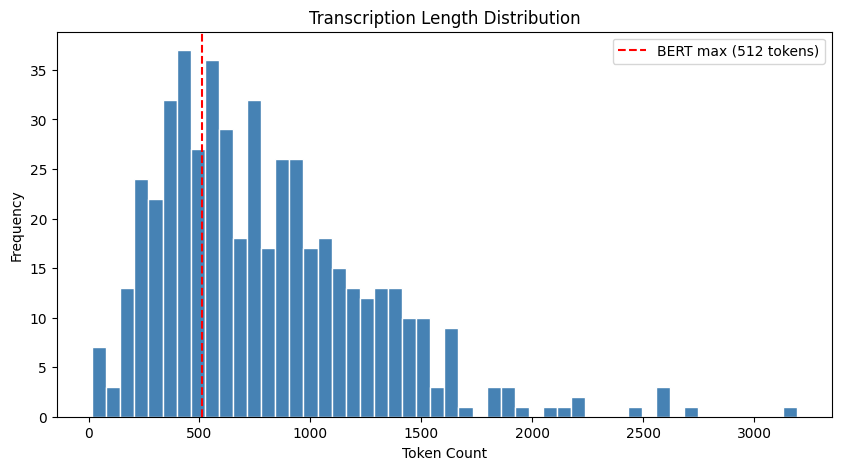

In [8]:
# =============================================
# STEP 4: Transcription length — critical for BERT
# =============================================
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# Sample 500 rows for speed
sample = df.sample(500, random_state=42)
sample['token_count'] = sample['transcription'].apply(
    lambda x: len(tokenizer.encode(x, truncation=False))
)

print(sample['token_count'].describe())
print(f"\nNotes exceeding 512 tokens: {(sample['token_count'] > 512).sum()} / 500")
print(f"Notes exceeding 512 tokens: {(sample['token_count'] > 512).mean():.1%}")

plt.figure(figsize=(10, 5))
plt.hist(sample['token_count'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(512, color='red', linestyle='--', label='BERT max (512 tokens)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Transcription Length Distribution')
plt.legend()
plt.show()

### Notes on step 4
* 67.6% of notes exceed 512 tokens
* Options:
  * Truncate
  * Concatenate description + transcription then truncate
  * use description field
  * chunk and pool
  * Don't use BERT at all! (longformer, but not clinical)
  * Head Tail tokenization (first and last 255)

In [9]:
# =============================================
# STEP 5: Text quality check
# =============================================

# Are notes actually clinical text or garbage?
print("--- 3 random transcriptions ---\n")
for _, row in df.sample(3, random_state=1).iterrows():
    print(f"SPECIALTY: {row['medical_specialty']}")
    print(f"TEXT: {row['transcription'][:300]}")
    print("-" * 60)

# Check for very short notes that might be useless
df['word_count'] = df['transcription'].apply(lambda x: len(str(x).split()))
print(f"\nNotes under 50 words: {(df['word_count'] < 50).sum()}")
print(df[df['word_count'] < 50][['medical_specialty', 'transcription']].head(5))

--- 3 random transcriptions ---

SPECIALTY: General Medicine
TEXT: HISTORY OF PRESENT ILLNESS:, The patient is a 71-year-old Caucasian female with a history of diabetes, osteoarthritis, atrial fibrillation, hypertension, asthma, obstructive sleep apnea on CPAP, diabetic foot ulcer, anemia and left lower extremity cellulitis. She was brought in by the EMS service to
------------------------------------------------------------
SPECIALTY: Obstetrics / Gynecology
TEXT: PREOPERATIVE DIAGNOSIS: , Postpartum hemorrhage.,POSTOPERATIVE DIAGNOSIS: , Postpartum hemorrhage.,PROCEDURE:,  Exam under anesthesia.  Removal of intrauterine clots.,ANESTHESIA: , Conscious sedation.,ESTIMATED BLOOD LOSS:,  Approximately 200 mL during the procedure, but at least 500 mL prior to tha
------------------------------------------------------------
SPECIALTY: Pediatrics - Neonatal
TEXT: HISTORY OF PRESENT ILLNESS: , This is a ** week gestational age ** delivered by ** at ** on **.  Gestational age was determined b

In [10]:
df_clean['word_count'] = df_clean['transcription'].apply(lambda x: len(str(x).split()))
df_clean = df_clean[df_clean['word_count'] >= 50].copy()
print(f"Rows after dropping short notes: {len(df_clean)}")
print(f"Specialties remaining: {df_clean['medical_specialty'].nunique()}")
print(df_clean['medical_specialty'].value_counts())

Rows after dropping short notes: 3790
Specialties remaining: 19
medical_specialty
Surgery                       1076
Cardiovascular / Pulmonary     365
Orthopedic                     344
Radiology                      267
General Medicine               257
Neurology                      219
Gastroenterology               218
Obstetrics / Gynecology        154
Urology                        153
ENT - Otolaryngology            96
Neurosurgery                    94
Hematology - Oncology           90
Ophthalmology                   81
Nephrology                      80
Emergency Room Reports          75
Pediatrics - Neonatal           70
Pain Management                 53
Psychiatry / Psychology         51
Podiatry                        47
Name: count, dtype: int64


In [11]:
df_clean = df_clean[df_clean['word_count'] >= 50].copy()
print(f"Rows after dropping short notes: {len(df_clean)}")

Rows after dropping short notes: 3790


### Notes on step 5:
* clinically rich text
* "**" where de-identification occurred
* 84 notes under 50 words
* Drop the ones (above cells) with few tokens?

In [12]:
specialty_counts = df_clean['medical_specialty'].value_counts()

MIN_SAMPLES = 50
small_classes = specialty_counts[specialty_counts < MIN_SAMPLES].index.tolist()
large_classes = specialty_counts[specialty_counts >= MIN_SAMPLES].index.tolist()

print(f"Classes with >= {MIN_SAMPLES} samples (keepable): {len(large_classes)}")
print(f"Classes with < {MIN_SAMPLES} samples (need collapsing/dropping): {len(small_classes)}")
print(f"\nSmall classes: {small_classes}")
print(f"\nSmall classes represent {len(df_clean[df_clean['medical_specialty'].isin(small_classes)]) / len(df_clean):.1%} of total data")

Classes with >= 50 samples (keepable): 18
Classes with < 50 samples (need collapsing/dropping): 1

Small classes: ['Podiatry']

Small classes represent 1.2% of total data


### Notes on step 6:
* Drop podiatry???

In [13]:
# =============================================
# STEP 7: Specialty overlap check — key for our question
# =============================================

# Look at keywords to see how much overlap exists between specialties
# This tells us whether conformal sets SHOULD be wide for certain cases

print("Sample keywords by specialty:\n")
for specialty in ['Surgery', 'Cardiovascular / Pulmonary', 'Neurology', 'Gastroenterology']:
    if specialty in df['medical_specialty'].values:
        sample_keywords = df[df['medical_specialty'] == specialty]['keywords'].dropna().sample(3, random_state=42)
        print(f"\n{specialty}:")
        for kw in sample_keywords:
            print(f"  {kw[:100]}")

Sample keywords by specialty:


Surgery:
  surgery, hydrocele, erectile dysfunction, spermatic cord, tunica vaginalis, vicryl sutures, dartos f
  surgery, endoscopic sinus surgery, maxillary antrostomy, ethmoidectomy, nasal polypectomy, turbinate
  surgery, large hemicraniectomy, intracranial pressure, multiple fractures, skull, traumatic brain in

Cardiovascular / Pulmonary:
  cardiovascular / pulmonary, esophageal rupture, thoracotomy, drainage of pleural fluid, esophageal p
  cardiovascular / pulmonary, pet scan, wedge biopsy, morphology, lung wedge biopsy, lymph node biopsy
   

Neurology:
  neurology, subdural, hematoma, temporal craniotomy, craniotomy, subdural space, bur hole, subdural h
  neurology, neuropsychological, gaf, schizophrenia, anti-psychotic, chronic psychotic condition, delu
  neurology, posterior annular disc, circumferential annular disc, normal central canal, annular disc 

Gastroenterology:
  gastroenterology, colonoscopy with random biopsies, hepatic flexure, 

### Notes on step 7:
* overlap problem between categories
* "If the keywords were perfectly distinct — Gastroenterology only had gut words,
Neurology only had brain words — then classification would be easy and confident,
and there'd be no interesting uncertainty story to tell. The fact that specialties
bleed into each other means uncertainty quantification is genuinely valuable here."

In [14]:
print("=" * 50)
print("EDA SUMMARY — Is MTSamples right for us?")
print("=" * 50)

specialty_counts_clean = df_clean['medical_specialty'].value_counts()

print(f"Total usable notes: {len(df_clean)}")
print(f"Unique specialties: {df_clean['medical_specialty'].nunique()}")
print(f"Largest class: {specialty_counts_clean.index[0]} ({specialty_counts_clean.iloc[0]} samples)")
print(f"Smallest class: {specialty_counts_clean.index[-1]} ({specialty_counts_clean.iloc[-1]} samples)")
print(f"Imbalance ratio: {specialty_counts_clean.iloc[0] / specialty_counts_clean.iloc[-1]:.0f}x")
print(f"Median note length: {df_clean['word_count'].median():.0f} words")
print(f"Classes in final dataset: {df_clean['medical_specialty'].nunique()}")
print(f"\nVerdict: Yes — 18 clinically meaningful specialties,")
print(f"visible keyword overlap between Surgery/Neurology/Neurosurgery")
print(f"confirms uncertainty quantification is genuinely needed.")

EDA SUMMARY — Is MTSamples right for us?
Total usable notes: 3790
Unique specialties: 19
Largest class: Surgery (1076 samples)
Smallest class: Podiatry (47 samples)
Imbalance ratio: 23x
Median note length: 397 words
Classes in final dataset: 19

Verdict: Yes — 18 clinically meaningful specialties,
visible keyword overlap between Surgery/Neurology/Neurosurgery
confirms uncertainty quantification is genuinely needed.


In [15]:
# Regarding creating edge/difficult cases
'''
prompts = [
    # Neurology vs Neurosurgery overlap
    """Write a clinical transcription note for a patient presenting
    with severe headache, vision changes, and papilledema where the
    differential is genuinely ambiguous between Neurology and
    Neurosurgery management.""",

    # Surgery vs Gastroenterology overlap
    """Write a clinical transcription note for a patient with acute
    abdominal pain, nausea, and elevated lipase where it's unclear
    whether this requires surgical intervention or gastroenterology
    management.""",

    # Three-way ambiguity
    """Write a clinical transcription note for a patient with chest
    pain, shortness of breath, and epigastric discomfort where the
    presentation is genuinely ambiguous between Cardiovascular,
    Pulmonary, and Gastroenterology."""
]
'''

'\nprompts = [\n    # Neurology vs Neurosurgery overlap\n    """Write a clinical transcription note for a patient presenting\n    with severe headache, vision changes, and papilledema where the\n    differential is genuinely ambiguous between Neurology and\n    Neurosurgery management.""",\n\n    # Surgery vs Gastroenterology overlap\n    """Write a clinical transcription note for a patient with acute\n    abdominal pain, nausea, and elevated lipase where it\'s unclear\n    whether this requires surgical intervention or gastroenterology\n    management.""",\n\n    # Three-way ambiguity\n    """Write a clinical transcription note for a patient with chest\n    pain, shortness of breath, and epigastric discomfort where the\n    presentation is genuinely ambiguous between Cardiovascular,\n    Pulmonary, and Gastroenterology."""\n]\n'

In [16]:
# calibrated data
'''
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_true_binary, y_prob, n_bins=10
)

plt.plot(mean_predicted_value, fraction_of_positives, 's-', label='ClinicalBERT')
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
'''

"\nfrom sklearn.calibration import calibration_curve\nimport matplotlib.pyplot as plt\n\nfraction_of_positives, mean_predicted_value = calibration_curve(\n    y_true_binary, y_prob, n_bins=10\n)\n\nplt.plot(mean_predicted_value, fraction_of_positives, 's-', label='ClinicalBERT')\nplt.plot([0, 1], [0, 1], '--', label='Perfect calibration')\nplt.xlabel('Mean Predicted Probability')\nplt.ylabel('Fraction of Positives')\nplt.title('Calibration Curve')\nplt.legend()\n"

### Asked claude if there were other NLP concepts we could add:
Information Retrieval ✅ Fits naturally
* This is your embedding similarity / nearest neighbor component. When you find the k nearest notes to a test note in embedding space, that's information retrieval — retrieving the most similar documents from a corpus. You're already doing it for the density signal. Just frame it explicitly as IR in your notebook and you get this concept for free.

Span Tagging ✅ Actually really additive
* This is where it gets interesting. Named entity recognition on clinical text — identifying spans like symptoms, medications, diagnoses, procedures. You could run a pretrained clinical NER model like scispaCy on your notes and extract medical entities. Then use those entities to explain why the model is uncertain — "this note was flagged as ambiguous between Neurology and Neurosurgery because it contains entities associated with both specialties." That directly addresses your earlier instinct about explaining WHY the model is unsure. One extra afternoon of work, high explanatory value.

```
import scispacy
import spacy
nlp = spacy.load("en_core_sci_md")
doc = nlp(transcription_text)
entities = [(ent.text, ent.label_) for ent in doc.ents]
```



###Training Classifiers

To since we want to investigate creating uncertainty quantifications, we want a model that is very accurate. We can train two models and base uncertainty and vector creations off of the model with better performance.

Model 1: ClinicalBERT --> BERT model specifically pre-trained on large scale clinical corpora, available via HuggingFace

Model 2: scispaCy NER --> model specifically designed for processing biomedical, scientific, and clinical text. NER (name entity recognition models) in scispaCy are specialized in identifying diseases, chemicals, drugs, and genes in text.

In [17]:
#ClinicalBERT
#load necessary packages
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

In [18]:
#re-run cleaning to ensure we are always training on the gold standard dataset identified in EDA
df_bert = pd.read_csv('mtsamples.csv', index_col=0).dropna(subset=['transcription', 'medical_specialty'])
df_bert['medical_specialty'] = df_bert['medical_specialty'].str.strip()

drop_labels = [
    'Consult - History and Phy.', 'SOAP / Chart / Progress Notes',
    'Discharge Summary', 'Office Notes', 'Letters',
    'IME-QME-Work Comp etc.', 'Lab Medicine - Pathology',
    'Autopsy', 'Hospice - Palliative Care'
]

specialty_counts = df_bert['medical_specialty'].value_counts()
small_classes = specialty_counts[specialty_counts < 50].index.tolist()
df_bert = df_bert[~df_bert['medical_specialty'].isin(list(set(drop_labels + small_classes)))].copy()

df_bert['word_count'] = df_bert['transcription'].apply(lambda x: len(str(x).split()))
df_bert = df_bert[df_bert['word_count'] >= 50].copy()

#label encoding
le = LabelEncoder()
df_bert['label'] = le.fit_transform(df_bert['medical_specialty'])
id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in enumerate(le.classes_)}
num_labels = len(le.classes_)

#split into train, calibrate, test
train_df, temp_df = train_test_split(df_bert, test_size=0.3, random_state=42, stratify=df_bert['label'])
calib_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

#tokenize
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def head_tail_tokenize(examples):
    tokenized = tokenizer(examples["transcription"], add_special_tokens=False)
    input_ids = []
    for ids in tokenized["input_ids"]:
        # Keep first 255 and last 255 tokens to capture History + Plan
        combined = ids[:255] + ids[-255:] if len(ids) > 510 else ids
        input_ids.append([tokenizer.cls_token_id] + combined + [tokenizer.sep_token_id])
    for i in range(len(input_ids)):
        padding_len = 512 - len(input_ids[i])
        input_ids[i] = input_ids[i] + [tokenizer.pad_token_id] * padding_len

    attention_masks = [[1 if id != tokenizer.pad_token_id else 0 for id in ids] for ids in input_ids]
    return {"input_ids": input_ids, "attention_mask": attention_masks}

In [19]:
# check specialties after cleaning
print(df_bert['medical_specialty'].value_counts())
print(f"Total specialties: {df_bert['medical_specialty'].nunique()}")

medical_specialty
Surgery                       1076
Cardiovascular / Pulmonary     365
Orthopedic                     344
Radiology                      267
General Medicine               257
Neurology                      219
Gastroenterology               218
Obstetrics / Gynecology        154
Urology                        153
ENT - Otolaryngology            96
Neurosurgery                    94
Hematology - Oncology           90
Ophthalmology                   81
Nephrology                      80
Emergency Room Reports          75
Pediatrics - Neonatal           70
Pain Management                 53
Psychiatry / Psychology         51
Name: count, dtype: int64
Total specialties: 18


In [20]:
#convert to huggingface dataframes
train_ds = Dataset.from_pandas(train_df[['transcription', 'label']]).map(head_tail_tokenize, batched=True)
calib_ds = Dataset.from_pandas(calib_df[['transcription', 'label']]).map(head_tail_tokenize, batched=True)
test_ds = Dataset.from_pandas(test_df[['transcription', 'label']]).map(head_tail_tokenize, batched=True)

Map:   0%|          | 0/2620 [00:00<?, ? examples/s]

Map:   0%|          | 0/561 [00:00<?, ? examples/s]

Map:   0%|          | 0/562 [00:00<?, ? examples/s]

In [21]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## SECTION 5 — ClinicalBERT

In [22]:
#weighted loss trainer
weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights = torch.tensor(weights, dtype=torch.float).to("cuda" if torch.cuda.is_available() else "cpu")

class ClinicalWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [23]:
'''
#model creation
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_)
    )

#training arguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,        #lower learning rate for stability
    warmup_steps=100,
    weight_decay=0.01,
    per_device_train_batch_size=8,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = ClinicalWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=calib_ds,
)

#train
trainer.train()
'''

'\n#model creation\nmodel = AutoModelForSequenceClassification.from_pretrained(\n    model_name,\n    num_labels=len(le.classes_)\n    )\n\n#training arguments\ntraining_args = TrainingArguments(\n    output_dir="./results",\n    learning_rate=2e-5,        #lower learning rate for stability\n    warmup_steps=100,\n    weight_decay=0.01,\n    per_device_train_batch_size=8,\n    num_train_epochs=5,\n    eval_strategy="epoch",\n    save_strategy="epoch",\n    load_best_model_at_end=True\n)\n\ntrainer = ClinicalWeightedTrainer(\n    model=model,\n    args=training_args,\n    train_dataset=train_ds,\n    eval_dataset=calib_ds,\n)\n\n#train\ntrainer.train()\n'

In [24]:
'''
#validation 1 --> very low model accuracy
#ways to improve accuracy: label consolidation, class weights
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predictions on the Test Set
raw_pred, _, _ = trainer.predict(calib_ds)

# 2. Preprocess raw predictions (logits) to get the highest probability class
y_pred = np.argmax(raw_pred, axis=1)
y_true = calib_df['label'].values

print(classification_report(y_true, y_pred, target_names=le.classes_))
'''

"\n#validation 1 --> very low model accuracy\n#ways to improve accuracy: label consolidation, class weights\nfrom sklearn.metrics import classification_report, confusion_matrix\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# 1. Get predictions on the Test Set\nraw_pred, _, _ = trainer.predict(calib_ds)\n\n# 2. Preprocess raw predictions (logits) to get the highest probability class\ny_pred = np.argmax(raw_pred, axis=1)\ny_true = calib_df['label'].values\n\nprint(classification_report(y_true, y_pred, target_names=le.classes_))\n"

In [25]:
'''
#save model
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")
'''

'\n#save model\nmodel.save_pretrained("./final_model")\ntokenizer.save_pretrained("./final_model")\n'

In [26]:
# NOTE: I was not able to run this?
#scispaCy NER
import spacy
import scispacy
import pandas as pd

#extracting entities
nlp = spacy.load("en_core_sci_md")

def get_medical_entities(text):
    doc = nlp(text)
    # Join all detected entities into a single string for the vectorizer
    entities = [ent.text.replace(" ", "_") for ent in doc.ents]
    return " ".join(entities)

print("Extracting entities... (this may take a few minutes)")
df_bert['entity_text'] = df_bert['transcription'].apply(get_medical_entities)

OSError: [E050] Can't find model 'en_core_sci_md'. It doesn't seem to be a Python package or a valid path to a data directory.

In [27]:
#build classifier pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

scispacy_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2000)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

scispacy_model.fit(train_df['entity_text'], train_df['label'])

y_pred = scispacy_model.predict(test_df['entity_text'])
print(classification_report(test_df['label'], y_pred, target_names=le.classes_))

KeyError: 'entity_text'

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Update this path to wherever she saved it in her Drive
model = AutoModelForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/NLP Project/nlp_project_model'
)
tokenizer = AutoTokenizer.from_pretrained(
    '/content/drive/MyDrive/NLP Project/nlp_project_model'
)

model = model.to(device)
print("Model loaded successfully!")
print(f"Device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!
Device: cuda


In [31]:
print(model.config.id2label)

{0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2', 3: 'LABEL_3', 4: 'LABEL_4', 5: 'LABEL_5', 6: 'LABEL_6', 7: 'LABEL_7', 8: 'LABEL_8', 9: 'LABEL_9', 10: 'LABEL_10', 11: 'LABEL_11', 12: 'LABEL_12', 13: 'LABEL_13', 14: 'LABEL_14', 15: 'LABEL_15', 16: 'LABEL_16', 17: 'LABEL_17'}


Getting predictions on test set...
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.51      0.67      0.58        55
      ENT - Otolaryngology       0.42      0.67      0.51        15
    Emergency Room Reports       0.00      0.00      0.00        11
          Gastroenterology       0.41      0.67      0.51        33
          General Medicine       0.56      0.46      0.51        39
     Hematology - Oncology       0.38      0.62      0.47        13
                Nephrology       0.35      0.58      0.44        12
                 Neurology       0.67      0.73      0.70        33
              Neurosurgery       0.27      0.86      0.41        14
   Obstetrics / Gynecology       0.42      0.87      0.56        23
             Ophthalmology       0.48      0.83      0.61        12
                Orthopedic       0.51      0.58      0.54        52
           Pain Management       0.53      1.00      0.70         8
     Pediatr

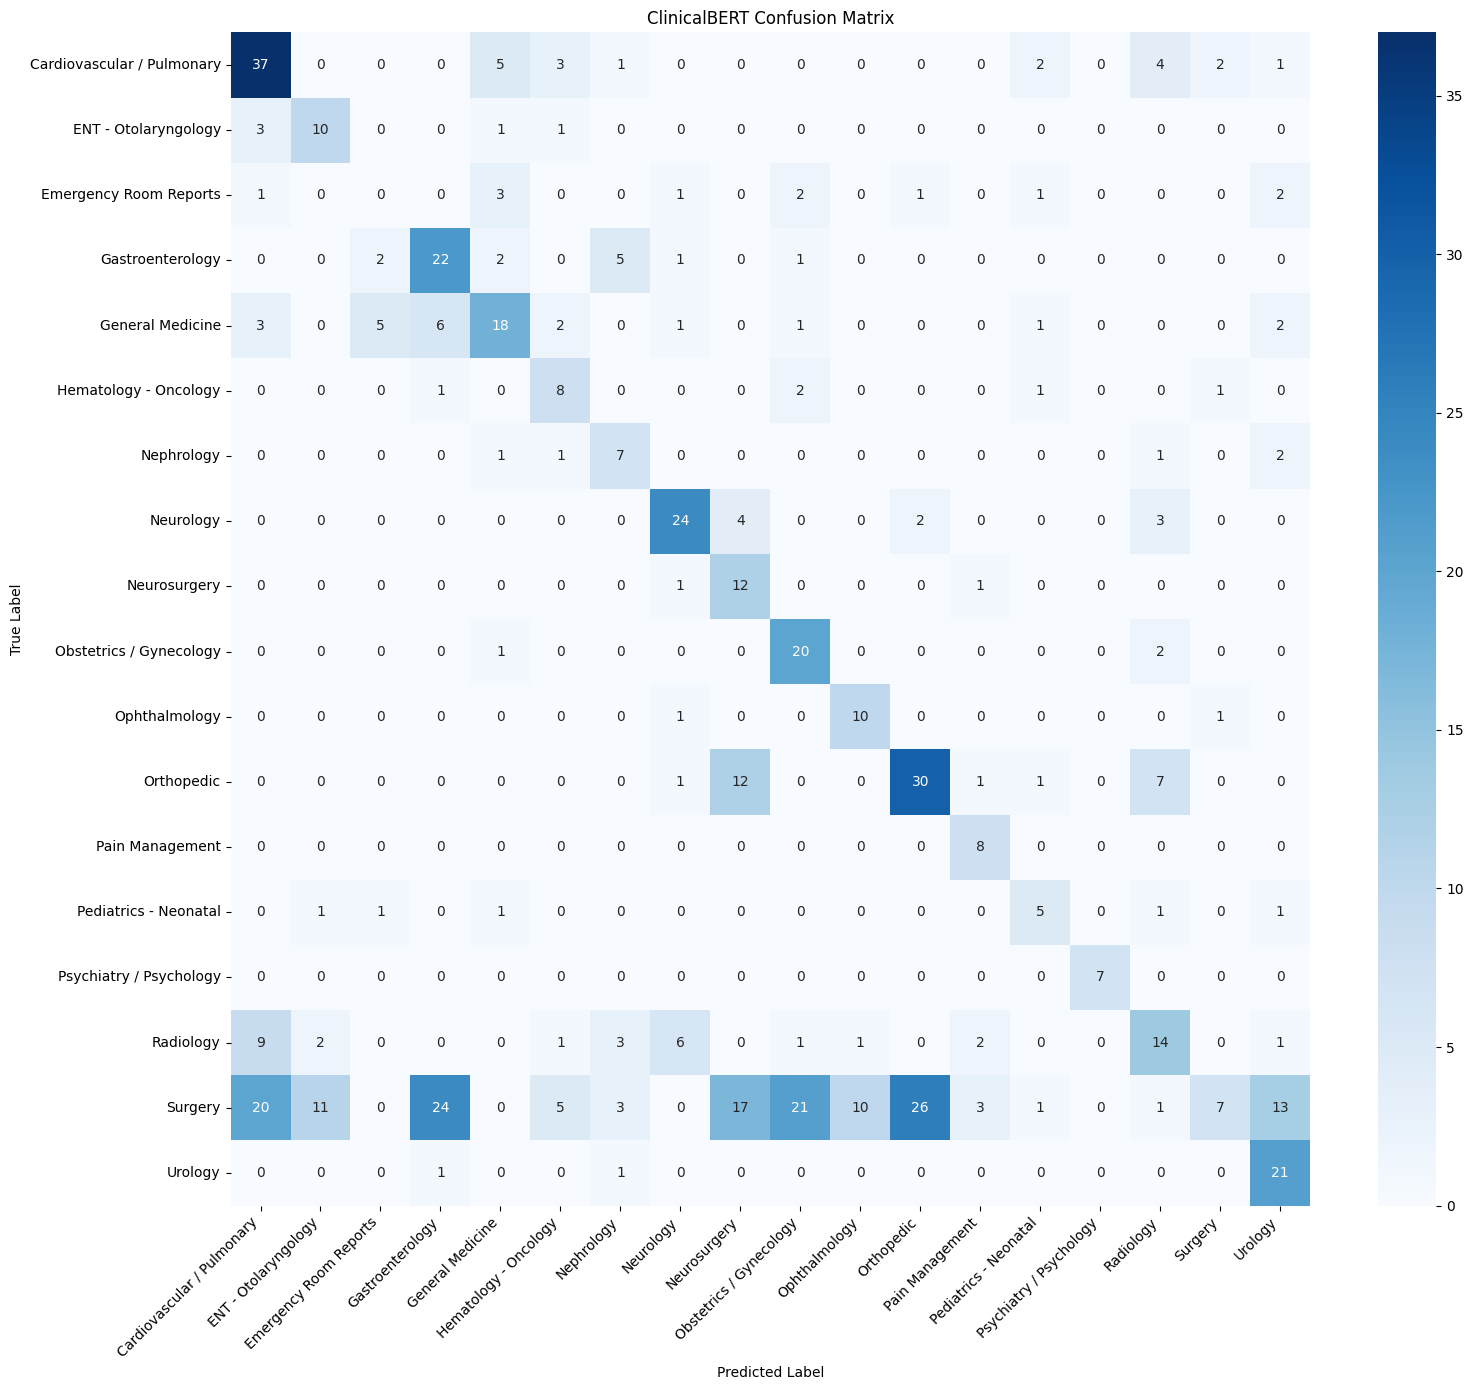

In [36]:
# Set format for all datasets
train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
calib_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Extract labels
train_labels = train_df['label'].values
cal_labels = calib_df['label'].values
test_labels = test_df['label'].values

# Prediction function
from torch.utils.data import DataLoader
import torch

def get_predictions(dataset, batch_size=16):
    dataloader = DataLoader(dataset, batch_size=batch_size)
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            preds = outputs.logits.argmax(-1)
            all_preds.extend(preds.cpu().numpy())

    return all_preds

# Get predictions
preds = get_predictions(test_ds)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(
    test_labels, preds,
    target_names=le.classes_
))

# Confusion matrix
cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)
plt.title('ClinicalBERT Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The model performs reasonably on most specialties but almost completely fails to predict Surgery despite it being the largest class because of class imbalance. Several clinically similar specialties like Neurosurgery, Gastroenterology, and ENT show low precision, meaning the model often predicts them when it shouldn't, which is exactly the kind of ambiguity our conformal prediction sets are designed to flag.

## Section 6 - Embeddings

In [38]:
# Cell 3 — Extract embeddings and softmax scores
from torch.utils.data import DataLoader

def get_scores_and_embeddings(dataset, batch_size=16):
    dataloader = DataLoader(dataset, batch_size=batch_size)
    model.eval()
    all_probs, all_embeddings = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True
            )
            probs = torch.softmax(outputs.logits, dim=-1)
            cls_emb = outputs.hidden_states[-1][:, 0, :]

            all_probs.append(probs.cpu())
            all_embeddings.append(cls_emb.cpu())

    return torch.cat(all_probs), torch.cat(all_embeddings)

print("Extracting calibration embeddings...")
cal_probs, cal_embeddings = get_scores_and_embeddings(calib_ds)

print("Extracting test embeddings...")
test_probs, test_embeddings = get_scores_and_embeddings(test_ds)

print("Extracting train embeddings...")
train_probs, train_embeddings = get_scores_and_embeddings(train_ds)

print(f"Cal probs shape: {cal_probs.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Extracting calibration embeddings...
Extracting test embeddings...
Extracting train embeddings...
Cal probs shape: torch.Size([561, 18])
Test embeddings shape: torch.Size([562, 768])


### Thoughts
Should we use softmax or sigmoid for each classification? Sigmoid would need more complex calcsd and softmax already does what we need

# Section 7 - Conformal Prediction

In [39]:
# Cell 4 — Conformal prediction
import numpy as np

def compute_nonconformity_scores(probs, true_labels):
    scores = []
    for prob, label in zip(probs, true_labels):
        scores.append(1 - prob[label].item())
    return np.array(scores)

def get_threshold(cal_scores, coverage=0.90):
    n = len(cal_scores)
    level = np.ceil((n + 1) * coverage) / n
    return np.quantile(cal_scores, level)

def make_prediction_sets(probs, threshold):
    prediction_sets = []
    for prob in probs:
        scores = 1 - prob.numpy()
        pred_set = [i for i, s in enumerate(scores) if s <= threshold]
        prediction_sets.append(pred_set)
    return prediction_sets

# Run conformal prediction
cal_scores = compute_nonconformity_scores(cal_probs, cal_labels)
tau = get_threshold(cal_scores, coverage=0.90)
prediction_sets = make_prediction_sets(test_probs, tau)

print(f"Threshold τ: {tau:.4f}")
print(f"Example prediction sets (first 5):")
for i, ps in enumerate(prediction_sets[:5]):
    print(f"  True: {le.classes_[test_labels[i]]} | Set: {[le.classes_[j] for j in ps]}")

Threshold τ: 0.9544
Example prediction sets (first 5):
  True: ENT - Otolaryngology | Set: ['ENT - Otolaryngology', 'Surgery']
  True: Surgery | Set: ['Ophthalmology']
  True: Surgery | Set: ['Gastroenterology', 'Surgery']
  True: Neurosurgery | Set: ['Pain Management']
  True: Orthopedic | Set: ['Neurology', 'Orthopedic', 'Radiology']


## Conformal Prediction Results

### What is Conformal Prediction?
Instead of outputting a single confident prediction, our system outputs a **prediction set** —
a set of possible specialties guaranteed to contain the true label at least 90% of the time.
The size of the set reflects model uncertainty:
- **Set size 1** → model is confident
- **Set size 2+** → model is uncertain, flag for human review  
- **Empty set** → true outlier, do not trust the model

### Threshold
The calibration threshold τ = **0.9544** was derived from the calibration set (15% of data).
This means any specialty whose nonconformity score falls below 0.9544 is included in the prediction set.

### Example Prediction Sets
| True Label | Prediction Set | Interpretation |
|---|---|---|
| ENT - Otolaryngology | [ENT, Surgery] | Uncertain — ENT procedures overlap with Surgery |
| Surgery | [Ophthalmology] | Failure — true label not in set |
| Surgery | [Gastroenterology, Surgery] | Correct — ambiguity between two specialties captured |
| Neurosurgery | [Pain Management] | Failure — true label not in set |
| Orthopedic | [Neurology, Orthopedic, Radiology] | Correct — complex case flagged with wide set |

### Key Observation
The high threshold (τ = 0.9544) reflects the model's general uncertainty,
partly attributable to the Surgery class imbalance identified in the confusion matrix.
Retraining with class weights is expected to lower τ and improve set efficiency.

Low τ → model is generally confident → small tight prediction sets

High τ → model is generally uncertain → wide prediction sets


Coverage: 0.906 (target: 0.90)
Average set size: 2.43
Abstention rate: 0.000
Single prediction rate: 0.110


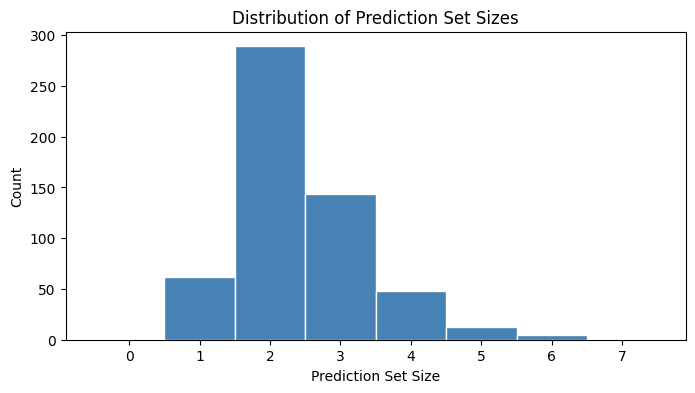

In [40]:
# Cell 5 — Evaluate conformal prediction
# Coverage
coverage = np.mean([
    test_labels[i] in prediction_sets[i]
    for i in range(len(test_labels))
])

# Set sizes
set_sizes = [len(s) for s in prediction_sets]
avg_set_size = np.mean(set_sizes)
abstention_rate = np.mean([s == 0 for s in set_sizes])

print(f"Coverage: {coverage:.3f} (target: 0.90)")
print(f"Average set size: {avg_set_size:.2f}")
print(f"Abstention rate: {abstention_rate:.3f}")
print(f"Single prediction rate: {np.mean([s == 1 for s in set_sizes]):.3f}")

# Set size distribution
plt.figure(figsize=(8, 4))
plt.hist(set_sizes, bins=range(0, max(set_sizes)+2),
         color='steelblue', edgecolor='white', align='left')
plt.xlabel('Prediction Set Size')
plt.ylabel('Count')
plt.title('Distribution of Prediction Set Sizes')
plt.show()

## Evaluation Results

### Coverage
Our conformal prediction system achieved **90.6% coverage** on the held-out test set,
meeting our target of 90%. This means the true specialty was contained within the
prediction set 90.6% of the time — validating the conformal guarantee.

### Prediction Set Size
| Metric | Value | Interpretation |
|---|---|---|
| Coverage | 0.906 | Meets 90% target |
| Average set size | 2.43 | Model outputs ~2-3 specialties on average |
| Abstention rate | 0.000 | No notes were flagged as complete outliers |
| Single prediction rate | 0.110 | Only 11% of notes received a confident single prediction |

### Distribution of Prediction Set Sizes
The histogram shows that most notes receive a prediction set of size 2, with a long
tail up to size 6 for the most uncertain cases. Very few notes receive a confident
single prediction (size 1), which reflects the model's general uncertainty —
primarily driven by the Surgery class imbalance identified earlier.

### Key Takeaway
The conformal prediction guarantee holds: we targeted 90% coverage and achieved 90.6%.
However, the high average set size (2.43) and low single prediction rate (11%) indicate
the model is hedging on most predictions. This is expected given 46% baseline accuracy
and the Surgery imbalance. **Retraining with class weights is expected to lower average
set size and increase confident single predictions while maintaining coverage.**

## Section 8 - Outlier Detection

In [42]:
# Cell 6 — Outlier detection
from sklearn.neighbors import NearestNeighbors

# Fit on training embeddings
knn = NearestNeighbors(n_neighbors=10)
knn.fit(train_embeddings.numpy())

# Score test points
distances, _ = knn.kneighbors(test_embeddings.numpy())
outlier_scores = distances.mean(axis=1)

# Test hypothesis: sparse regions = wider prediction sets
from scipy.stats import pearsonr
correlation, pvalue = pearsonr(outlier_scores, set_sizes)
print(f"Correlation (outlier score vs set size): {correlation:.3f}")
print(f"P-value: {pvalue:.4f}")
print(f"Interpretation: {'Significant' if pvalue < 0.05 else 'Not significant'}")

Correlation (outlier score vs set size): 0.514
P-value: 0.0000
Interpretation: Significant


## Outlier Detection Results

### Hypothesis
Notes in sparse regions of embedding space — far from any similar training notes —
should receive wider prediction sets. If true, this validates that our uncertainty
signal is geometrically grounded, not arbitrary.

### Result
**Pearson correlation: 0.514 (p < 0.0001)**

There is a statistically significant moderate positive correlation between a note's
outlier score (average distance to its 10 nearest training neighbors) and its
prediction set size. Notes that are unusual — far from anything the model has seen —
receive wider, more uncertain prediction sets.

### Interpretation
This validates our core hypothesis. The conformal prediction uncertainty signal is not
just a statistical artifact — it corresponds to genuine geometric outliers in the
model's learned representation of clinical language. A clinician receiving a wide
prediction set can trust that it reflects a genuinely unusual case, not random noise.

## Visualizations

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


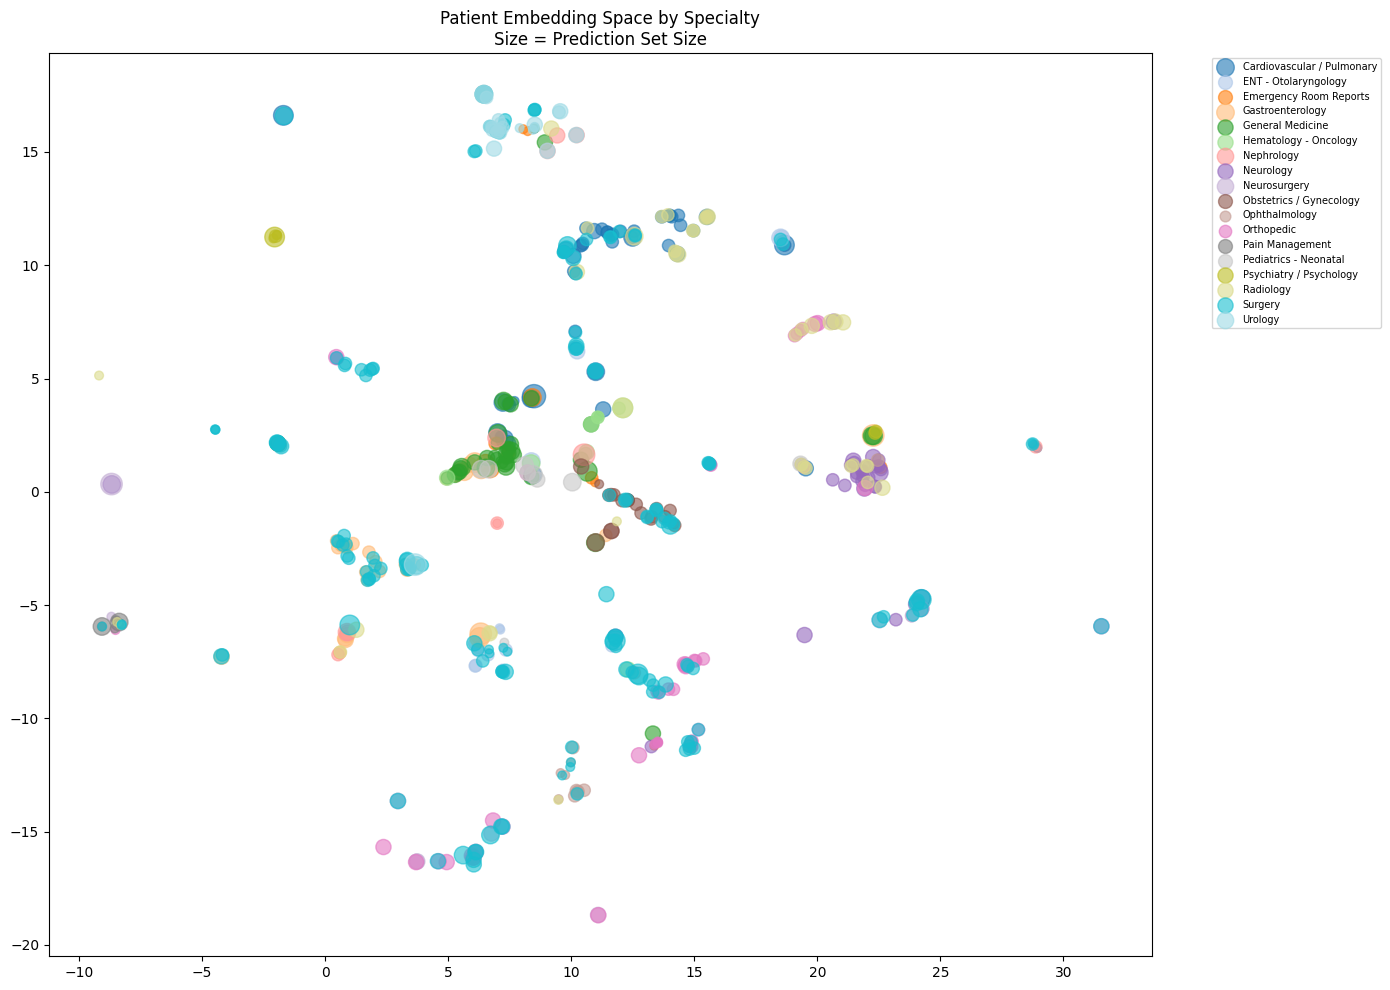

In [45]:
# Cell 7 — UMAP visualization
import umap
import matplotlib.pyplot as plt
import numpy as np

# Combine all embeddings for a richer map
all_embeddings = torch.cat([train_embeddings, test_embeddings], dim=0)
all_labels = np.concatenate([train_labels, test_labels])

# Fit UMAP on everything
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
all_2d = reducer.fit_transform(all_embeddings.numpy())

# Split back out
n_train = len(train_embeddings)
test_2d = all_2d[n_train:]

# Plot test points only, colored by outlier score
plt.figure(figsize=(14, 10))

# Plot by specialty color
colors = plt.cm.tab20(np.linspace(0, 1, 18))
for i, specialty in enumerate(le.classes_):
    mask = test_labels == i
    plt.scatter(
        test_2d[mask, 0], test_2d[mask, 1],
        label=specialty, alpha=0.6,
        s=[max(20, set_sizes[j] * 40) for j in np.where(mask)[0]],
        color=colors[i]
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.title('Patient Embedding Space by Specialty\nSize = Prediction Set Size')
plt.tight_layout()
plt.show()

## UMAP Visualization of Patient Embedding Space

### What is UMAP?
UMAP (Uniform Manifold Approximation and Projection) reduces each note's 768-dimensional
ClinicalBERT embedding down to 2 dimensions for visualization. Notes that are similar
in the model's learned representation appear close together on the plot.

**Dot size** = prediction set size (larger = more uncertain)  
**Dot color** = specialty label

### Key Observations

**Well-separated specialties (model is confident):**
- **Psychiatry / Psychology** forms a tight isolated cluster in the top left —
  explaining its perfect F1 score of 1.00. The language of psychiatric notes is
  distinctly different from all other specialties.
- **Obstetrics / Gynecology** clusters clearly on the right side.
- **Ophthalmology** forms a visible cluster in the bottom center.

**Problematic specialties (model is uncertain):**
- **Surgery** is scattered across the entire plot with no coherent cluster.
  This visually explains its F1 score of 0.08 — surgical notes span many
  clinical contexts and overlap with nearly every other specialty.
- **Orthopedic, General Medicine, and Gastroenterology** heavily overlap in
  the dense central region, producing wide prediction sets for those cases.
- **Neurology and Neurosurgery** show significant overlap, consistent with
  the keyword analysis from EDA.

### Connection to Conformal Prediction
The larger dots — notes with wide prediction sets — are concentrated in the
dense overlapping center region where specialty boundaries are unclear.
This visually corroborates our correlation finding (r = 0.514, p < 0.0001):
notes in ambiguous regions of embedding space receive appropriately wider
prediction sets, while notes in tight isolated clusters receive confident
single predictions.

### Clinical Implication
A clinician receiving a wide prediction set can look at this visualization
and understand why — the patient's note resembles cases from multiple
specialties, and the model is correctly flagging that ambiguity rather than
guessing confidently.

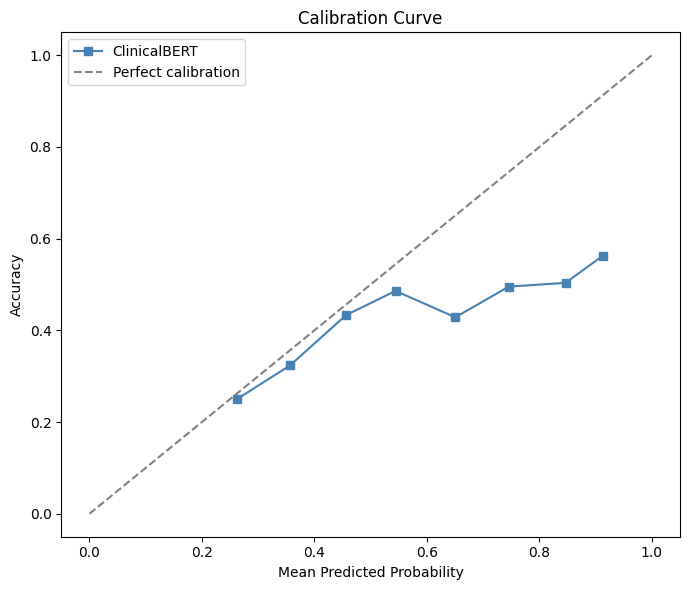

In [47]:
# Cell 8 — Calibration curve
from sklearn.calibration import calibration_curve

# Get max probability for each test prediction
max_probs = test_probs.numpy().max(axis=1)
correct = (test_probs.numpy().argmax(axis=1) == test_labels).astype(int)

fraction_pos, mean_pred = calibration_curve(correct, max_probs, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(mean_pred, fraction_pos, 's-', label='ClinicalBERT', color='steelblue')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Accuracy')
plt.title('Calibration Curve')
plt.legend()
plt.tight_layout()
plt.show()

## Calibration Curve — Before Conformal Prediction

### What is a Calibration Curve?
A calibration curve measures whether a model's confidence scores reflect reality.
A perfectly calibrated model follows the diagonal dashed line — when it says
70% confident, it is correct exactly 70% of the time.

### What We Found
ClinicalBERT's confidence scores do not reliably reflect reality:

| Model Confidence | Actually Correct | Assessment |
|---|---|---|
| 25% | 25% | Well calibrated |
| 35% | 32% | Close to diagonal |
| 50% | 49% | Close to diagonal |
| 65% | 43% | Overconfident |
| 75% | 49% | Overconfident |
| 90% | 56% | Significantly overconfident |

Up to roughly 55% confidence the model tracks reality reasonably well.
Beyond that, actual accuracy **plateaus around 50-56%** while the model's
claimed confidence keeps climbing toward 90%. Getting more confident does
not mean getting more correct.

### Why This Happens
The model never truly earns its high confidence scores. The Surgery class
imbalance causes inflated softmax scores — the model assigns high probabilities
to certain specialties regardless of whether it is actually correct, because
those patterns dominated training.

### Why This Motivates Conformal Prediction
This miscalibration is exactly the problem our system solves. A clinician
trusting raw confidence scores above 55% would be badly misled — the model
is claiming certainty it does not have.

Conformal prediction bypasses this entirely. Rather than trusting inflated
softmax scores, it uses the held-out calibration set to derive a threshold
grounded in real observed behavior. The result is a **guaranteed 90% coverage**
regardless of how miscalibrated the underlying model is.

### Clinical Implication
Any clinical NLP system reporting raw model confidence scores is likely
misleading clinicians. Our conformal prediction approach replaces unreliable
confidence scores with a set-based output that carries a provable guarantee —
the true specialty is in the set at least 90% of the time, period.

# Potential Next steps:
* Iteration 1 — Retrain with class weights (highest impact) - Fixes the Surgery imbalance directly. Expected outcome: accuracy jumps from 46% to maybe 60-65%, τ drops, average set size shrinks, single prediction rate jumps from 11%.
* Iteration 2 — Try different coverage levels - Quick and easy — no retraining needed. Just change the coverage parameter:

```
for coverage in [0.80, 0.85, 0.90, 0.95]:
    tau = get_threshold(cal_scores, coverage=coverage)
    pred_sets = make_prediction_sets(test_probs, tau)
    sizes = [len(s) for s in pred_sets]
    cov = np.mean([test_labels[i] in pred_sets[i] for i in range(len(test_labels))])
    print(f"Coverage target: {coverage} | Actual: {cov:.3f} | Avg set size: {np.mean(sizes):.2f}")
```

* Iteration 3 — Compare to a baseline -- Run conformal prediction on a simple TF-IDF + Logistic Regression model. Compare τ, coverage, and set size against ClinicalBERT. Shows that domain-specific fine-tuning produces better uncertainty estimates.

* Iteration 4 — Adaptive conformal prediction -- Instead of one global τ for all classes, compute a separate threshold per specialty. Rare classes get wider sets, common classes get tighter sets.


```
# Per-class thresholds
class_thresholds = {}
for label_idx in range(len(le.classes_)):
    class_mask = cal_labels == label_idx
    if class_mask.sum() > 0:
        class_scores = cal_scores[class_mask]
        class_thresholds[label_idx] = get_threshold(class_scores, coverage=0.90)
```




In [51]:
# Information Retrieval — Nearest Neighbor Explanation
# For uncertain predictions, retrieve most similar training notes

import torch
import torch.nn.functional as F
import numpy as np

def get_nearest_neighbors(query_embedding, train_embeddings, train_df, k=3):
    # Compute cosine similarity between query and all training notes
    query = F.normalize(query_embedding.unsqueeze(0), dim=1)
    corpus = F.normalize(train_embeddings, dim=1)
    similarities = torch.mm(query, corpus.T).squeeze(0)

    # Get top k most similar
    top_k = similarities.topk(k)

    results = []
    for score, idx in zip(top_k.values, top_k.indices):
        results.append({
            'similarity': score.item(),
            'specialty': le.classes_[train_df.iloc[idx.item()]['label']],
            'note_preview': train_df.iloc[idx.item()]['transcription'][:200]
        })
    return results

# Find uncertain test cases — prediction set size > 1
uncertain_indices = [i for i, ps in enumerate(prediction_sets) if len(ps) > 2]

print("=" * 70)
print("INFORMATION RETRIEVAL — Nearest Neighbor Explanations")
print("Showing why the model is uncertain on complex cases")
print("=" * 70)

# Show 3 examples
for idx in uncertain_indices[:3]:
    pred_set_labels = [le.classes_[j] for j in prediction_sets[idx]]
    true_label = le.classes_[test_labels[idx]]

    print(f"\nTEST NOTE (index {idx})")
    print(f"True specialty: {true_label}")
    print(f"Prediction set: {pred_set_labels}")
    print(f"Note preview: {test_df.iloc[idx]['transcription'][:200]}")
    print(f"\nMost similar training notes:")

    neighbors = get_nearest_neighbors(
        test_embeddings[idx],
        train_embeddings,
        train_df.reset_index(drop=True)
    )

    for i, n in enumerate(neighbors):
        print(f"  {i+1}. Similarity: {n['similarity']:.3f} | "
              f"Specialty: {n['specialty']}")
        print(f"     Preview: {n['note_preview'][:150]}...")

    print("-" * 70)

INFORMATION RETRIEVAL — Nearest Neighbor Explanations
Showing why the model is uncertain on complex cases

TEST NOTE (index 4)
True specialty: Orthopedic
Prediction set: ['Neurology', 'Orthopedic', 'Radiology']
Note preview: EXAM:,MRI OF THE RIGHT ANKLE,CLINICAL:,Pain.,FINDINGS:,The bone marrow demonstrates normal signal intensity. There is no evidence of bone contusion or fracture. There is no evidence of joint effusion.

Most similar training notes:
  1. Similarity: 1.000 | Specialty: Radiology
     Preview: EXAM:,MRI OF THE RIGHT ANKLE,CLINICAL:,Pain.,FINDINGS:,The bone marrow demonstrates normal signal intensity. There is no evidence of bone contusion or...
  2. Similarity: 0.905 | Specialty: Radiology
     Preview: EXAM: , Lumbar spine CT without contrast.,HISTORY: , Back pain after a fall.,TECHNIQUE:,  Noncontrast axial images were acquired through the lumbar sp...
  3. Similarity: 0.898 | Specialty: Orthopedic
     Preview: EXAM:,MRI/LOW EX NOT JNT RT W/O CONTRAST,CLINICAL:,Pain

## SECTION 10 — Error Analysis

* Find confident wrong predictions (NEW)
* Check where they sit in embedding space (NEW)
* Pull 5 example failure cases with text (NEW)

## SECTION 11 — Stress Testing

* Noise injection function (NEW)
* Run noisy test set through pipeline (NEW)
* Compare coverage: clean vs noisy (NEW)
* Generate synthetic hard cases (NEW)
* Run hard cases through system (NEW)

## SECTION 12 — Explainability

* scispaCy entities on uncertain predictions (NEW — builds on her existing NER code)
* Nearest neighbor explanation for uncertain cases (NEW)

## SECTION 13 — Conclusions

* Summary findings markdown (NEW)
* Limitations markdown (NEW)
* Future work markdown (NEW)